# 03 — The reality check: real Gaia stars

Notebook 02 finished with a model scoring **PR-AUC 0.9992** and **99.58% recall** on held-out
data, having deliberately refused the one shortcut (sky position) that would have inflated it
dishonestly. By every check available inside that notebook, it works.

Every one of those checks was run on **simulated** stars.

The training set comes from the Gaia Object Generator — a model of what Gaia would see, not
what Gaia saw. Held-out rows from a simulation test whether the model *generalises*; they
cannot test whether the simulation *is right*. Those are different questions, and only the
second one decides whether this model is worth anything.

So here we hand it real data:

| catalogue | stars | what they are |
| --- | --- | --- |
| `xm_cepheids_LMC-result.csv` | 4,485 | Classical Cepheids, cross-matched to Gaia EDR3 |
| `xm_rrlyrae_LMC-result.csv` | 22,006 | RR Lyrae, same |

Both are **confirmed LMC members**, identified by variability — a completely independent
method that uses none of the astrometry the model sees. If the model learned the physics of a
gravitationally bound population, it should tag them. If it learned the simulation, it should
not.

**This notebook does not fix anything.** It establishes how real-sky performance can honestly
be measured, measures it, and stops on the result. The diagnosis is notebook 04.

In [1]:
import json
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy import stats

import lmc
from lmc import models
from lmc.split import SEED, make_dev_lock

DATA = Path("../data")
PROCESSED = DATA / "processed"

LMC_C, MW_C, REAL_C = "#ff8c42", "#6b8cae", "#2ec4b6"

sim = lmc.load_sim(verbose=True)
print(f"simulated: {sim.height:,} rows, {int(sim['Type'].sum()):,} of them LMC")

  loaded 1,269,704 rows from data/processed/train_clean.parquet
simulated: 1,269,704 rows, 277,177 of them LMC


## 1. Loading real Gaia — three traps before any science

The simulated file has 12 tidy columns. These have 99, straight out of the ESA archive, and
three things about them will silently corrupt an analysis if you load them the obvious way.

### Trap 1: the header is padded with spaces

The RR Lyrae export was written with its header visually aligned into columns. Polars takes
column names literally, so about a dozen of them arrive with leading whitespace — and one of
them is `parallax_error`, a model feature. The Cepheid file is clean, so the two catalogues
end up with *different schemas*, and the bug surfaces as a `KeyError` deep into an analysis
rather than at load time.

In [2]:
raw_ceph = pl.read_csv(DATA / "xm_cepheids_LMC-result.csv", n_rows=5)
raw_rrl  = pl.read_csv(DATA / "xm_rrlyrae_LMC-result.csv",  n_rows=5)

print("Cepheid file, first 8 column names (repr, so whitespace is visible):")
for c in raw_ceph.columns[:8]:
    print(f"    {c!r}")

print("\nRR Lyrae file, the same 8:")
for c in raw_rrl.columns[:8]:
    print(f"    {c!r}")

padded = [c for c in raw_rrl.columns if c != c.strip()]
print(f"\n{len(padded)} padded names in the RR Lyrae file: {[c.strip() for c in padded]}")
print(f"'parallax_error' present as written?  {'parallax_error' in raw_rrl.columns}")
print("...which is a model feature, so this is not cosmetic.")

Cepheid file, first 8 column names (repr, so whitespace is visible):
    'solution_id'
    'designation'
    'source_id'
    'random_index'
    'ref_epoch'
    'ra'
    'ra_error'
    'dec'

RR Lyrae file, the same 8:
    'solution_id'
    '        designation'
    '                  source_id'
    '          random_index'
    'ref_epoch'
    'ra'
    '         ra_error'
    '  dec'

8 padded names in the RR Lyrae file: ['designation', 'source_id', 'random_index', 'ra_error', 'dec', 'dec_error', 'parallax_error', 'parallax_over_error']
'parallax_error' present as written?  False
...which is a model feature, so this is not cosmetic.


### Trap 2: not every star has the astrometry we need

Gaia does not solve all five astrometric parameters for every source. Faint or badly-observed
stars get a two-parameter solution — position only, no parallax and no proper motion. Those
rows arrive with nulls in exactly the columns the model depends on.

This matters more than it looks. `df.select(features).to_numpy()` turns a null into `NaN`, and
XGBoost happily accepts `NaN`: it routes it to a **default direction** learned during training.
But the cleaned simulated training set has *zero* missing values, so that default direction
was never trained on anything. Whatever those stars score is arbitrary — and it would be
folded straight into the recall figure.

So: drop them explicitly, count them, and quote the denominator every single time.

### Trap 3: the derived columns already exist

The real files ship Gaia's own `bp_rp` and `parallax_over_error`. Recomputing them from the
component columns — the way the simulated set requires — has to give the same answer, or the
two domains are being described in different units. Worth one assertion rather than one
assumption.

In [3]:
real = pl.concat([lmc.load_real_catalogue(n, verbose=True) for n in ("cepheid", "rrlyrae")])

print(f"\ncombined: {real.height:,} rows")
for cat in ("cepheid", "rrlyrae"):
    s = real.filter(pl.col("catalogue") == cat)
    print(f"  {cat:<8} {s.height:>6,} total   "
          f"{int(s['astrometry_ok'].sum()):>6,} with astrometry   "
          f"{int(s['photometry_ok'].sum()):>6,} with photometry")

# Trap 3: our recomputed columns against Gaia's published ones.
chk = lmc.strip_headers(pl.read_csv(DATA / "xm_rrlyrae_LMC-result.csv",
                                    infer_schema_length=20_000, ignore_errors=True))
gaia_bp_rp = chk["bp_rp"].cast(pl.Float64, strict=False).to_numpy()
ours_bp_rp = real.filter(pl.col("catalogue") == "rrlyrae")["bp_rp"].to_numpy()
m = np.isfinite(gaia_bp_rp) & np.isfinite(ours_bp_rp)
print(f"\nbp_rp: ours vs Gaia's own column, max|diff| = {np.abs(gaia_bp_rp[m] - ours_bp_rp[m]).max():.2e}"
      f" over {m.sum():,} rows")
assert np.abs(gaia_bp_rp[m] - ours_bp_rp[m]).max() < 1e-4
print("same definition on both sides.")

  cepheid  4,485 rows   10 without astrometry, 8 without photometry
  rrlyrae  22,006 rows   80 without astrometry, 619 without photometry

combined: 26,491 rows
  cepheid   4,485 total    4,475 with astrometry    4,477 with photometry
  rrlyrae  22,006 total   21,926 with astrometry   21,387 with photometry



bp_rp: ours vs Gaia's own column, max|diff| = 1.88e-06 over 21,387 rows
same definition on both sides.


## 2. Before blaming the model — are these stars actually where the model expects?

There are two ways a model can score badly on new data, and they demand opposite responses:
the model is wrong, or the new data is not what you thought it was. Ruling out the second
comes first.

The claim under test is narrow. The model's single strongest signal is proper motion: the LMC
moves as one bound object, so its members share a velocity. If these real Cepheids and
RR Lyrae are genuine members, their proper motions must land on the same clump the simulation
puts them in. If they do not, any disagreement afterwards is about the catalogues, not the
classifier.

In [4]:
is_lmc = (sim["Type"] == 1).to_numpy()
sim_pmra, sim_pmdec = sim["pmra"].to_numpy(), sim["pmdec"].to_numpy()
mu_ra, mu_dec = np.median(sim_pmra[is_lmc]), np.median(sim_pmdec[is_lmc])

ok = real.filter(pl.col("astrometry_ok"))
rows = [("simulated LMC", sim_pmra[is_lmc], sim_pmdec[is_lmc])]
for cat in ("cepheid", "rrlyrae"):
    s = ok.filter(pl.col("catalogue") == cat)
    rows.append((f"real {cat}", s["pmra"].to_numpy(), s["pmdec"].to_numpy()))
rows.append(("simulated MW", sim_pmra[~is_lmc], sim_pmdec[~is_lmc]))

# MAD -> sigma: the median absolute deviation times 1.4826 estimates the standard
# deviation of a Gaussian, without a handful of outliers dragging it around.
k = 1.4826
print(f"{'population':<16} {'n':>9}   {'median pmra':>12} {'median pmdec':>13}"
      f" {'spread ra':>11} {'spread dec':>11}   {'offset':>7}")
for name, a, d in rows:
    ma, md_ = np.median(a), np.median(d)
    sa = k * np.median(np.abs(a - ma))
    sd = k * np.median(np.abs(d - md_))
    off = np.hypot(ma - mu_ra, md_ - mu_dec)
    print(f"{name:<16} {len(a):>9,}   {ma:>12.3f} {md_:>13.3f} {sa:>11.3f} {sd:>11.3f}   {off:>7.3f}")

print(f"\noffset = distance of that population's centroid from the simulated LMC's, in mas/yr")

population               n    median pmra  median pmdec   spread ra  spread dec    offset


simulated LMC      277,177          1.858         0.385       0.170       0.152     0.000
real cepheid         4,475          1.796         0.332       0.286       0.381     0.081
real rrlyrae        21,926          1.846         0.364       0.445       0.605     0.024
simulated MW       992,527          1.111         5.187       5.204       5.848     4.860

offset = distance of that population's centroid from the simulated LMC's, in mas/yr


Read the `offset` column. Both real catalogues sit within a few hundredths of a mas/yr of the
simulated LMC's centroid, while the simulated Milky Way sits several mas/yr away. **These are
LMC members, and the simulation puts the LMC in the right place.**

Read the `spread` columns too, because they are not as reassuring. The real populations are
noticeably wider than the simulated one. Park that — it becomes section 4 of notebook 04.

## 3. The rule that keeps the rest of this project honest

There is a trap ahead that is easy to walk into and impossible to walk back out of.

Once real-sky recall is a number on screen, every subsequent decision — which features to
keep, which to drop, where to put a threshold — will be made while watching it. At that point
these 26,000 stars have stopped being a test set and become a training set, and the final
figure quoted is a number the design was fitted to.

So the catalogues are **halved now, before anything is measured**:

- **`dev`** — everything in notebooks 03, 04 and 05 is measured here. Look at it as often as
  you like.
- **`lock`** — untouched until notebook 06. Every headline figure in the README, the model
  card and the website comes from this half and nowhere else.

The halves are stratified on G magnitude. Faintness is the dominant driver of astrometric
noise, so an unstratified split could differ in median brightness by enough to move recall a
few points on its own — which would look like a result.

In [5]:
g = real["phot_g_mean_mag"].to_numpy()
real = real.with_columns(pl.Series("split", make_dev_lock(g, seed=SEED)))

PROCESSED.mkdir(parents=True, exist_ok=True)
real.write_parquet(PROCESSED / "real_lmc.parquet", compression="zstd")
print(f"wrote {PROCESSED / 'real_lmc.parquet'}  ({real.height:,} rows, {len(real.columns)} columns)\n")

# The model needs all eleven features, so a star is scoreable only if it has BOTH
# astrometry and photometry. That intersection is the denominator every recall
# figure in this project divides by, so it gets printed rather than assumed.
scoreable = pl.col("astrometry_ok") & pl.col("photometry_ok")

print(f"{'':<10} {'total':>8} {'scoreable':>11} {'dev':>8} {'lock':>8}")
for cat in ("cepheid", "rrlyrae"):
    s = real.filter(pl.col("catalogue") == cat)
    ok = s.filter(scoreable)
    print(f"{cat:<10} {s.height:>8,} {ok.height:>11,} "
          f"{ok.filter(pl.col('split') == 'dev').height:>8,} "
          f"{ok.filter(pl.col('split') == 'lock').height:>8,}")

for half in ("dev", "lock"):
    gg = real.filter(pl.col("split") == half)["phot_g_mean_mag"].to_numpy()
    print(f"\n{half:<5} median G = {np.nanmedian(gg):.4f}", end="")
print("\n\nThe two halves match to four decimal places in brightness — the stratification worked.")

wrote ../data/processed/real_lmc.parquet  (26,491 rows, 26 columns)

              total   scoreable      dev     lock
cepheid       4,485       4,467    2,254    2,213
rrlyrae      22,006      21,327   10,665   10,662

dev   median G = 19.2709
lock  median G = 19.2709

The two halves match to four decimal places in brightness — the stratification worked.


## 4. What can, and cannot, be measured on this data

Every star in both catalogues is an LMC member. There are **no negatives**. That single fact
rules out most of the metrics notebook 02 relied on, and it is worth being blunt about which:

| quantity | on the simulated test set | here |
| --- | --- | --- |
| **recall** — of the real members, how many did we keep? | ✔ | ✔ |
| **purity / precision** — of what we claimed, how much is real? | ✔ | ✘ *no negatives to contaminate with* |
| **PR-AUC, ROC-AUC** | ✔ | ✘ *both need both classes* |
| **accuracy** | ✔ (and useless — 78% for free) | ✘ |

So this notebook quotes recall, and never quotes a purity figure on real data. Anywhere. That
restriction holds for the rest of the project.

It comes with an obvious hole, which section 5 plugs: **a model that answers "LMC" to
everything scores 100% recall.** Recall alone, on positives-only data, is not evidence.

In [6]:
n_dev = int(real.filter((pl.col("split") == "dev") & pl.col("astrometry_ok")).height)
print("a model that simply always answers 'LMC':")
print(f"  recall on the dev half = {100 * n_dev / n_dev:.2f}%   ({n_dev:,}/{n_dev:,})")
print("  purity                 = undefined, there is nothing here it could get wrong")
print("\nSo any recall number below is meaningless until paired with a control. Section 5.")

a model that simply always answers 'LMC':
  recall on the dev half = 100.00%   (13,195/13,195)
  purity                 = undefined, there is nothing here it could get wrong

So any recall number below is meaningless until paired with a control. Section 5.


### Why notebook 02's headline number was the wrong one to celebrate

Notebook 02 reported ROC-AUC 0.9998 and PR-AUC 0.9992 side by side, and the first is the more
flattering of the two by design. Under class imbalance they answer different questions.

Both are built from the same counts. For a threshold $t$:

$$\text{recall} = \frac{TP}{TP + FN} \qquad
  \text{precision} = \frac{TP}{TP + FP} \qquad
  \text{FPR} = \frac{FP}{FP + TN}$$

ROC plots recall against **FPR**, which divides the false positives by the number of
*negatives* — 198,506 of them in the test set. A thousand contaminants move that denominator
by half a percent, so ROC-AUC barely notices them. Precision divides the same false positives
by the number of stars you actually **claimed**, which is a far smaller number, so it feels
every one.

Average precision is the area under the precision-recall curve, summed as a step function:

$$\mathrm{AP} = \sum_n (R_n - R_{n-1})\, P_n$$

Ten lines of numpy, and worth writing out once — the subtlety is that stars with *identical*
scores cannot be separated by any threshold, so they must count as one step. Miss that and AP
comes out too high exactly when a model is confident enough to tie many predictions at 1.0.

In [7]:
def average_precision(y_true, score):
    order = np.argsort(-score, kind="stable")
    y, s = np.asarray(y_true)[order], np.asarray(score)[order]

    cut = np.r_[np.flatnonzero(np.diff(s)), len(y) - 1]   # last index of each tied group
    tp, fp = np.cumsum(y)[cut], np.cumsum(1 - y)[cut]
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / max(y.sum(), 1)
    return float(np.sum(np.diff(np.r_[0.0, recall]) * precision))


from sklearn.metrics import average_precision_score, roc_auc_score

rng = np.random.default_rng(0)
for tag, maker in [
    ("continuous scores", lambda y: y * 0.5 + rng.normal(0, 0.3, len(y))),
    ("many ties at 0/1",  lambda y: np.clip(y * 0.5 + rng.normal(0, 0.3, len(y)), 0, 1)),
    ("heavily tied",      lambda y: np.round(np.clip(y * 0.5 + rng.normal(0, 0.3, len(y)), 0, 1), 1)),
]:
    yy = (rng.random(20_000) < 0.22).astype(int)
    ss = maker(yy)
    ours, theirs = average_precision(yy, ss), average_precision_score(yy, ss)
    assert abs(ours - theirs) < 1e-9
    print(f"  {tag:<18} ours {ours:.10f} == sklearn {theirs:.10f}")
print("\nmatches sklearn exactly, ties included.")

  continuous scores  ours 0.7037270004 == sklearn 0.7037270004
  many ties at 0/1   ours 0.6992869947 == sklearn 0.6992869947
  heavily tied       ours 0.6739363507 == sklearn 0.6739363507

matches sklearn exactly, ties included.


And the demonstration that makes the difference concrete. A classifier with an ROC-AUC most
people would call excellent, producing a catalogue that is mostly contamination:

In [8]:
n = 200_000
base = 0.02                                  # a rare class, as membership problems usually are
y_demo = (rng.random(n) < base).astype(int)
score_demo = rng.normal(np.where(y_demo == 1, 3.0, 0.0), 1.0)

roc = roc_auc_score(y_demo, score_demo)
ap = average_precision(y_demo, score_demo)

# Pick the threshold that keeps 90% of the real members — a normal operating choice.
t = np.quantile(score_demo[y_demo == 1], 0.10)
pred = score_demo >= t
tp = int((pred & (y_demo == 1)).sum()); fp = int((pred & (y_demo == 0)).sum())

print(f"base rate {100*base:.0f}%   ROC-AUC {roc:.4f}   PR-AUC {ap:.4f}")
print(f"at 90% recall:  {tp:,} real  +  {fp:,} contaminants")
print(f"                purity = {100*tp/(tp+fp):.1f}%   FPR = {100*fp/(y_demo==0).sum():.2f}%")
print(f"\nROC-AUC {roc:.4f} looks superb. The catalogue is {100*fp/(tp+fp):.0f}% junk.")
print("The false positives are large next to the positives and tiny next to the negatives,")
print("and ROC-AUC only ever compares them to the negatives.")

base rate 2%   ROC-AUC 0.9821   PR-AUC 0.7524
at 90% recall:  3,573 real  +  9,216 contaminants
                purity = 27.9%   FPR = 4.70%

ROC-AUC 0.9821 looks superb. The catalogue is 72% junk.
The false positives are large next to the positives and tiny next to the negatives,
and ROC-AUC only ever compares them to the negatives.


### One more tool: how precise is a recall figure?

Every number below is "$k$ of $n$ stars recovered" — a binomial proportion on 2,200 or 11,000
trials. Quoting `97.16%` bare invites the question "±what?", and the textbook interval
$\hat p \pm z\sqrt{\hat p(1-\hat p)/n}$ is the wrong tool here: at recalls near 1 it runs past
100%, and it is badly off-centre for small $k$.

The Wilson interval inverts the score test instead — it asks which values of $p$ the data
would *not* have rejected:

$$\frac{\hat p + \frac{z^2}{2n} \;\pm\; z\sqrt{\frac{\hat p(1-\hat p)}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}$$

which stays inside $[0, 1]$ by construction. Five lines, and it is checked against a bootstrap
rather than trusted.

In [9]:
def naive_ci(k, n, z=1.959963984540054):
    p = k / n
    half = z * np.sqrt(p * (1 - p) / n)
    return p - half, p + half


def wilson_ci(k, n, z=1.959963984540054):
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    half = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)


print(f"{'k / n':>13}   {'naive':>18}   {'Wilson':>18}")
for k, n in [(23, 100), (503, 2254), (8193, 10665), (99, 100)]:
    nv, w = naive_ci(k, n), wilson_ci(k, n)
    print(f"{k:>6,}/{n:<6,}   [{100*nv[0]:6.2f}, {100*nv[1]:6.2f}]   [{100*w[0]:6.2f}, {100*w[1]:6.2f}]")
print("\nThe last row is the tell: the naive interval reaches above 100%, which is not a")
print("probability. But 'looks wrong' is not an argument, so test what an interval is for.")

# An interval claiming 95% confidence should contain the true value 95% of the time.
# Simulate datasets from a KNOWN p and count. This is the only check that matters.
print(f"\n{'true p':>8} {'n':>7}   {'naive covers':>13} {'Wilson covers':>14}   (nominal 95%)")
for p_true in (0.23, 0.80, 0.97, 0.995):
    for n in (100, 2000):
        draws = rng.binomial(n, p_true, 4000)
        cov_n = np.mean([lo <= p_true <= hi for lo, hi in (naive_ci(k, n) for k in draws)])
        cov_w = np.mean([lo <= p_true <= hi for lo, hi in (wilson_ci(k, n) for k in draws)])
        flag = "  <-- naive fails" if cov_n < 0.90 else ""
        print(f"{p_true:>8.3f} {n:>7,}   {100*cov_n:>12.1f}% {100*cov_w:>13.1f}%{flag}")

print("\nNear the boundary the naive interval quietly stops being a 95% interval at all.")
print("Every recall in this project sits near a boundary, so: Wilson.")

        k / n                naive               Wilson
    23/100      [ 14.75,  31.25]   [ 15.84,  32.15]
   503/2,254    [ 20.60,  24.03]   [ 20.64,  24.08]
 8,193/10,665   [ 76.02,  77.62]   [ 76.01,  77.61]
    99/100      [ 97.05, 100.95]   [ 94.55,  99.82]

The last row is the tell: the naive interval reaches above 100%, which is not a
probability. But 'looks wrong' is not an argument, so test what an interval is for.

  true p       n    naive covers  Wilson covers   (nominal 95%)
   0.230     100           95.0%          95.5%
   0.230   2,000           94.9%          94.8%
   0.800     100           93.1%          94.0%
   0.800   2,000           95.1%          95.3%
   0.970     100           79.7%          96.8%  <-- naive fails
   0.970   2,000           95.2%          94.7%
   0.995     100           40.0%          91.1%  <-- naive fails
   0.995   2,000           92.3%          96.0%

Near the boundary the naive interval quietly stops being a 95% interval at all.
Every r

## 5. The control: negatives that do not exist, built honestly

Recall on positives-only data is unfalsifiable on its own, so we need something the model
should *reject*. There are no real foreground stars in these files, so we make some — and the
construction has to be stated precisely, because a badly-built control proves nothing.

**Construction.** Take the real stars, keep everything about them — their magnitudes, their
colours, their parallaxes, their measurement errors — and replace only their proper motion
with a draw from the *simulated Milky Way's* proper-motion distribution.

**What that gives us.** A population with real Gaia photometry and real Gaia error scales,
moving like foreground stars. If the model is doing what it claims — separating on shared
bulk motion — it must reject these while keeping the originals. If it accepts both, its recall
means nothing. If it rejects both, the failure is not about motion at all.

**What it is not.** These are synthetic, and the pairing is artificial: real Milky Way stars in
this direction would not have the magnitude distribution of LMC Cepheids. It is a control, not
a measurement, and the number it produces is labelled *pseudo-purity* everywhere it appears —
never purity.

In [10]:
dev = real.filter((pl.col("split") == "dev") & pl.col("astrometry_ok") & pl.col("photometry_ok"))
print(f"dev half, fully scoreable rows: {dev.height:,}")

# Its own generator, not the shared `rng`. Otherwise which Milky Way stars get drawn
# depends on how many random numbers the cells above happened to consume, and adding
# a demonstration anywhere earlier would silently move this result.
rng_ctrl = np.random.default_rng(SEED)

mw_pmra, mw_pmdec = sim_pmra[~is_lmc], sim_pmdec[~is_lmc]
pick = rng_ctrl.choice(len(mw_pmra), size=dev.height, replace=False)

control = dev.with_columns([
    pl.Series("pmra", mw_pmra[pick]),
    pl.Series("pmdec", mw_pmdec[pick]),
]).drop(["pm_total", "bp_rp", "plx_snr"]).pipe(lmc.add_derived)

print(f"control built: {control.height:,} stars with real photometry and foreground motion\n")
print(f"{'':<22} {'median pmra':>12} {'median pmdec':>13}")
print(f"{'real dev stars':<22} {np.median(dev['pmra']):>12.3f} {np.median(dev['pmdec']):>13.3f}")
print(f"{'synthetic controls':<22} {np.median(control['pmra']):>12.3f} {np.median(control['pmdec']):>13.3f}")
print(f"{'simulated Milky Way':<22} {np.median(mw_pmra):>12.3f} {np.median(mw_pmdec):>13.3f}")
print(f"\nphotometry untouched: median G = {np.median(dev['phot_g_mean_mag']):.3f} in both, by construction")

dev half, fully scoreable rows: 12,919
control built: 12,919 stars with real photometry and foreground motion

                        median pmra  median pmdec
real dev stars                1.833         0.354
synthetic controls            1.115         5.176


simulated Milky Way           1.111         5.187

photometry untouched: median G = 19.268 in both, by construction


## 6. Running the model

`outputs/v1_baseline/` — the model notebook 02 trained, unmodified, on its eleven features.

In [11]:
model_dir, clf, FEATURES = models.load("v1_baseline")
print(f"model:    {model_dir.name}")
print(f"features: {', '.join(FEATURES)}\n")

def score(frame):
    return clf.predict_proba(frame.select(FEATURES).to_numpy().astype(np.float32))[:, 1]

p_control = score(control)

print(f"{'catalogue':<12} {'recall @ 0.5':>34}   {'median P(LMC)':>14}")
results = {}
for cat in ("cepheid", "rrlyrae"):
    s = dev.filter(pl.col("catalogue") == cat)
    p = score(s)
    k, n = int((p >= 0.5).sum()), len(p)
    results[cat] = {"k": k, "n": n, "p": p}
    lo, hi = wilson_ci(k, n)
    print(f"{cat:<12} {100*k/n:>8.2f}% [{100*lo:5.2f}, {100*hi:5.2f}] ({k:>6,}/{n:<6,})"
          f"   {np.median(p):>14.4f}")

kept_control = int((p_control >= 0.5).sum())
print(f"\n{'control':<12} {100*kept_control/len(p_control):>8.2f}% accepted "
      f"({kept_control:,}/{len(p_control):,})   {np.median(p_control):>14.4f}")

tp = sum(r["k"] for r in results.values())
print(f"\npseudo-purity (synthetic control, NOT purity): {100*tp/(tp+kept_control):.2f}%")

model:    v1_baseline
features: pmra, pmdec, pm_total, parallax, pmra_error, pmdec_error, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, bp_rp

catalogue                          recall @ 0.5    median P(LMC)
cepheid         22.32% [20.64, 24.08] (   503/2,254 )           0.0071
rrlyrae         76.82% [76.01, 77.61] ( 8,193/10,665)           0.9808

control          1.50% accepted (194/12,919)           0.0000

pseudo-purity (synthetic control, NOT purity): 97.82%


Read the control line first, because it decides how to read everything above it.

The model rejected **98.5%** of the synthetic foreground, with a median assigned probability
of 0.0000. It is not answering "LMC" to whatever it is handed — it discriminates, and it
discriminates on motion, exactly as designed. So the recall figures above are real
measurements rather than the artifact of a degenerate classifier.

And they are bad. The RR Lyrae figure, 76.8%, is poor for a model advertised at 99.58%. The
Cepheid figure is not poor, it is a **collapse**: 22.3%, with a median assigned probability of
**0.0071**. The model is not hesitating over these stars. It is confident they are foreground.

These are the same stars whose proper-motion centroid we measured two sections ago at
0.081 mas/yr from the simulated LMC's — dead centre in the clump the model exists to find.

One possibility to eliminate immediately: is this just a badly-placed threshold? If the model
ranked these stars correctly but scaled its probabilities differently on real data, moving the
cut would recover them.

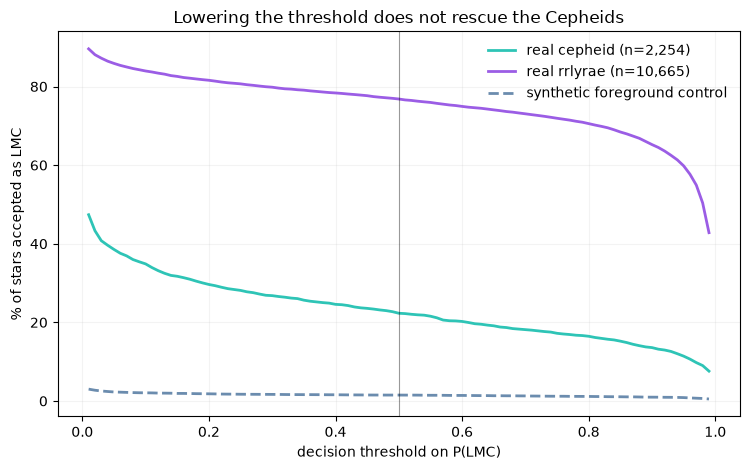

recall if we drop the threshold all the way to 0.10:
  cepheid     34.87%   (control also accepted: 2.07%)
  rrlyrae     83.95%   (control also accepted: 2.07%)


In [12]:
grid = np.linspace(0.01, 0.99, 99)

fig, ax = plt.subplots(figsize=(7.6, 4.8))
for cat, c in (("cepheid", REAL_C), ("rrlyrae", "#9b5de5")):
    p = results[cat]["p"]
    ax.plot(grid, [100*(p >= t).mean() for t in grid], color=c, lw=2,
            label=f"real {cat} (n={len(p):,})")
ax.plot(grid, [100*(p_control >= t).mean() for t in grid], color=MW_C, lw=2, ls="--",
        label="synthetic foreground control")
ax.axvline(0.5, color="k", lw=0.8, alpha=0.4)
ax.set_xlabel("decision threshold on P(LMC)")
ax.set_ylabel("% of stars accepted as LMC")
ax.set_title("Lowering the threshold does not rescue the Cepheids")
ax.legend(frameon=False)
ax.grid(alpha=0.15)
plt.tight_layout(); plt.show()

print("recall if we drop the threshold all the way to 0.10:")
for cat in ("cepheid", "rrlyrae"):
    p = results[cat]["p"]
    print(f"  {cat:<10} {100*(p >= 0.10).mean():6.2f}%   "
          f"(control also accepted: {100*(p_control >= 0.10).mean():.2f}%)")

Not a threshold problem. At a cut of 0.10 — accepting anything with a one-in-ten chance —
Cepheid recall reaches 34.9%. The model has not mis-scaled its confidence; it has put these
stars on the wrong side of its decision surface and it holds that opinion firmly.

## 7. The picture

Simulated LMC members in grey, showing the clump the model trained on. Real stars on top,
coloured by the probability the model gives them.

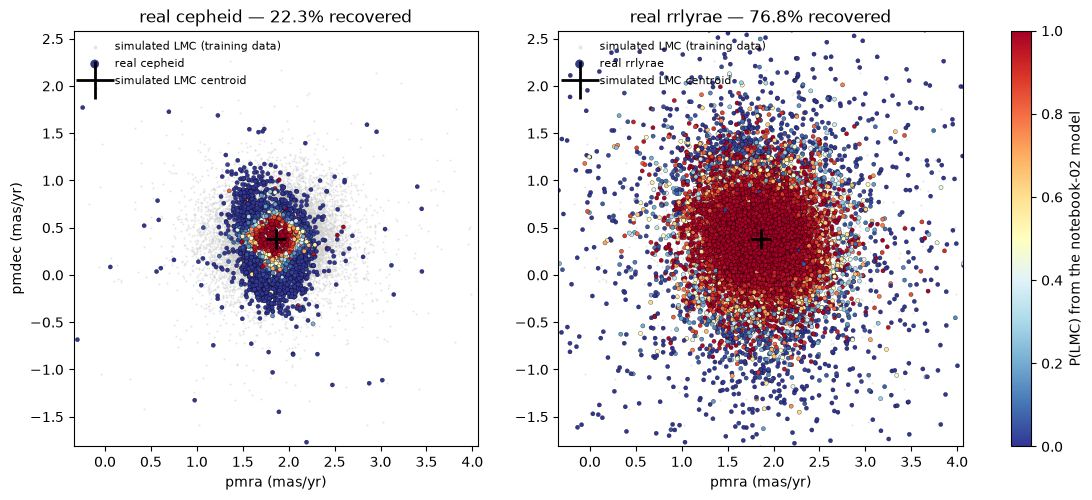

fraction accepted, by distance from the simulated LMC centroid:
offset (mas/yr)       cepheid    rrlyrae
0.0 – 0.2              98.4%     99.8%
0.2 – 0.4              23.6%     99.7%
0.4 – 0.6               1.6%     99.0%
0.6 – 1.0               2.0%     77.5%
1.0 – 3.0               0.0%     22.2%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.4))

rng_fig = np.random.default_rng(SEED)
sub = rng_fig.choice(np.flatnonzero(is_lmc), 40_000, replace=False)

for ax, cat in zip(axes, ("cepheid", "rrlyrae")):
    s = dev.filter(pl.col("catalogue") == cat)
    p = results[cat]["p"]
    ax.scatter(sim_pmra[sub], sim_pmdec[sub], s=2, c="#cccccc", alpha=0.5, lw=0,
               label="simulated LMC (training data)")
    sc = ax.scatter(s["pmra"], s["pmdec"], c=p, s=9, cmap="RdYlBu_r", vmin=0, vmax=1,
                    lw=0.2, edgecolor="k", label=f"real {cat}")
    ax.plot(mu_ra, mu_dec, "k+", ms=14, mew=2, label="simulated LMC centroid")
    ax.set_xlim(mu_ra - 2.2, mu_ra + 2.2); ax.set_ylim(mu_dec - 2.2, mu_dec + 2.2)
    ax.set_xlabel("pmra (mas/yr)")
    ax.set_title(f"real {cat} — {100*results[cat]['k']/results[cat]['n']:.1f}% recovered")
    ax.legend(loc="upper left", frameon=False, fontsize=8, markerscale=2)

axes[0].set_ylabel("pmdec (mas/yr)")
fig.colorbar(sc, ax=axes, label="P(LMC) from the notebook-02 model", fraction=0.025)
plt.show()

# The tolerance the two panels are drawn with, as a number rather than an impression.
print("fraction accepted, by distance from the simulated LMC centroid:")
print(f"{'offset (mas/yr)':<18} {'cepheid':>10} {'rrlyrae':>10}")
for lo, hi in [(0.0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 1.0), (1.0, 3.0)]:
    line = f"{lo:.1f} – {hi:.1f}".ljust(18)
    for cat in ("cepheid", "rrlyrae"):
        s = dev.filter(pl.col("catalogue") == cat)
        off = np.hypot(s["pmra"].to_numpy() - mu_ra, s["pmdec"].to_numpy() - mu_dec)
        m = (off >= lo) & (off < hi)
        line += f"{100*(results[cat]['p'][m] >= 0.5).mean():9.1f}%" if m.sum() > 20 else f"{'-':>10}"
    print(line)

Both panels show the same galaxy, and the model has drawn a **completely different acceptance
region** in each. The table underneath puts a number on it:

| offset from the LMC centroid | Cepheids accepted | RR Lyrae accepted |
| --- | --- | --- |
| 0.0 – 0.2 mas/yr | 98.4% | 99.8% |
| **0.2 – 0.4** | **23.6%** | **99.7%** |
| 0.4 – 0.6 | 1.6% | 99.0% |
| 0.6 – 1.0 | 2.0% | 77.5% |
| 1.0 – 3.0 | 0.0% | 22.2% |

Right at the centre the model accepts both populations. Two-tenths of a mas/yr out — still
comfortably inside the grey cloud of simulated members — Cepheid acceptance has fallen off a
cliff to 23.6% while RR Lyrae acceptance is *untouched* at 99.7%.

The model's tolerance in proper-motion space is roughly **0.2 mas/yr for Cepheids and 0.6–1.0
for RR Lyrae**. A factor of three to five, between two populations that differ in nothing an
astronomer would call relevant: both are variable stars in the same galaxy, bound to it, moving
with it.

So the model does not have a rule about proper motion. It has a rule whose *tolerance* is set
by something else — and that something else is overriding the signal carrying 93.7% of its
importance.

## 8. What this notebook establishes

- The real catalogues load cleanly once three traps are handled: eight padded column names in
  the RR Lyrae file — including `parallax_error`, a model feature — rows with no astrometric
  solution that would otherwise reach XGBoost as untrained `NaN`s, and derived columns that
  must be computed identically on both sides (checked: max difference 1.9e-06).
- **These stars really are LMC members.** Cepheid and RR Lyrae proper-motion centroids sit
  0.081 and 0.024 mas/yr from the simulated LMC's, against 4.860 for the simulated foreground.
  Any disagreement afterwards is the model's.
- On positives-only data **recall is measurable and purity is not**. This project does not
  quote a purity figure on real data again.
- Recall alone is unfalsifiable — always-yes scores 100% — so it is paired throughout with a
  synthetic foreground control, which the model rejects 98.5% of the time.
- The model that scores **99.58% recall on simulated held-out data** recovers **22.3% of real
  Cepheids** (median P = 0.0071) and **76.8% of real RR Lyrae**.
- Not a threshold artifact: dropping the cut to 0.10 reaches only 34.9% on Cepheids.
- **Its proper-motion tolerance is not fixed** — 0.2 mas/yr for one population, 0.6–1.0 for the
  other, in the same galaxy.
- The real populations are wider in proper motion than the simulated one (spread 0.29 and 0.45
  against 0.17 mas/yr). Noted, unexplained, picked up in notebook 04.

The uncomfortable part: notebook 02's methodology was not sloppy. The held-out split, the
stratification, the refusal to use sky position, reporting recall and purity rather than
accuracy — all correct, and none of it could have caught this. Every one of those checks asks
whether the model generalises *within* its training distribution. Not one asks whether that
distribution resembles the sky.

**Next — notebook 04: why.** A variable tolerance is a strong clue: something the model uses is
telling it how much scatter to expect, and that something reads differently on real stars. Three
independent lines of evidence, and a mechanism precise enough to predict which stars fail before
the model is run on them.